# Link Prediction mit GATv2 auf dem OpenFlights-Flugroutennetz

Die Daten kommen aus `processed/openflights_split.pt`, erzeugt durch `data_prep_OpenFlights.ipynb` (dort auch die
Beschreibung des Datensatzes und die Heuristik-Baselines). Modell, Eingangsschicht, Decoder, Trainingsloop und
Hyperparameter sind identisch zu `GINE_OpenFlights.ipynb`, nur das Message Passing unterscheidet sich.

**Aufgabe:** Ein Teil der Flugrouten ist aus dem Graphen entfernt. Das Modell soll für Flughafenpaare
entscheiden, ob dort eine Route existiert. Die Negativ-Paare haben dieselbe Entfernungsverteilung wie echte Routen
und dasselbe „Loch“ im Graphen (`neg_strategy="distance"`), Luftlinie und Grad-Loch helfen also nicht.

**Messlatte (Test, aus `data_prep_OpenFlights.ipynb`):** Adamic-Adar ≈ 0.75, Gemeinsame Nachbarn ≈ 0.74,
Preferential Attachment ≈ 0.68, Luftlinie ≈ 0.57.

**Wichtige Entscheidungen** (Begründung im Abschnitt Hyperparameter):
- Decoder `mode="hadamard"` (h_u ⊙ h_v) statt `concat`: Flugrouten sind ungerichtet, das elementweise Produkt ist
  symmetrisch und misst direkt, wie gut zwei Embeddings zusammenpassen.
- Hyperparameter per Tuning auf der Val-AUC gewählt (Test nie zur Auswahl verwendet).

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

from gnn_pipeline import (
    load_bundle, set_seed, EdgeAwareInput, LinkDecoder, batch_norm, count_parameters, split_graph,
    train_link_predictor, evaluate_link_predictor, run_seeds, plot_learning_curves, auc_by_bucket, link_scores,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

bundle = load_bundle("processed/openflights_split.pt", device=device)
data, train_data, val_data, test_data = bundle.data, bundle.train, bundle.val, bundle.test

in_channels = data.x.size(1)
edge_dim = data.edge_attr.size(1)

C:\Users\gurke\PycharmProjects\MethodenDerKI_GraphEmbedding\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\gurke\PycharmProjects\MethodenDerKI_GraphEmbedding\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Device: cpu
Split geladen: processed/openflights_split.pt
Knoten: 3214 {'America': 1225, 'Asia': 786, 'Europe': 565, 'Africa': 260, 'Pacific': 175, 'Australia': 112, 'Atlantic': 32, 'Other': 30, 'Indian': 29}, Kanten: 37716
Knotenfeatures (14): ['sphere_x', 'sphere_y', 'sphere_z', 'log_altitude', 'utc_offset', 'region_Africa', 'region_America', 'region_Asia', 'region_Atlantic', 'region_Australia', 'region_Europe', 'region_Indian', 'region_Pacific', 'region_Other']
Kantenfeatures (6): ['distance_km', 'n_airlines', 'n_route_entries', 'n_aircraft_types', 'codeshare_share', 'bidirectional']
train: msg-passing Kanten=21120, Label-Paare pos=9052 neg=9052
val: msg-passing Kanten=21120, Label-Paare pos=3772 neg=3772
test: msg-passing Kanten=21120, Label-Paare pos=3772 neg=3772
train: positive Label-Kanten im Message-Passing-Graph: 0/9052, davon Gegenrichtung im Graph: 0/9052 (0.0%)
val: positive Label-Kanten im Message-Passing-Graph: 0/3772, davon Gegenrichtung im Graph: 0/3772 (0.0%)
test: po

## GATv2: Graph Attention Network v2 mit Kantenfeatures

Die Nachbarn werden mit gelernten Attention-Gewichten gemittelt, die Kantenfeatures
(Entfernung, Zahl der Airlines, …) fließen in die Gewichte ein:

$$\alpha_{ij} = \mathrm{softmax}_j\Big(a^\top \mathrm{LeakyReLU}\big(W_l x_j + W_r x_i + W_e e_{ji}\big)\Big), \qquad x_i' = \sum_j \alpha_{ij}\, W_l x_j$$

**Was GATv2 hier lernen kann:** Welche Nachbarn wichtig sind, z. B. stark beflogene Verbindungen mit vielen
Airlines stärker gewichten als eine einzelne Regionalroute. Den Grad sieht GATv2 nicht direkt (Softmax mittelt),
er kommt über die gemeinsame Eingangsschicht `EdgeAwareInput` (Summe der eingehenden Kantenfeatures) hinein.

**Architektur:** `EdgeAwareInput` → 3 × `GATv2Conv` (4, 4, 1 Heads; 128 Kanäle nach dem Concat) mit BatchNorm,
ELU und Dropout → Knoten-Embeddings → `LinkDecoder`.

In [2]:
from torch_geometric.nn import GATv2Conv

class GATv2LinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_dim, heads=4, dropout=0.3,
                 decoder="hadamard"):
        super().__init__()
        if hidden_channels % heads:
            raise ValueError("hidden_channels muss durch heads teilbar sein.")
        per_head = hidden_channels // heads   # concat der Heads ergibt wieder hidden_channels
        # gemeinsame Eingangsschicht (identisch zu GINE): Knotenfeatures + Summe der eingehenden Kantenfeatures
        self.input = EdgeAwareInput(in_channels, edge_dim, hidden_channels)
        self.conv1 = GATv2Conv(hidden_channels, per_head, heads=heads, edge_dim=edge_dim, concat=True)
        self.conv2 = GATv2Conv(hidden_channels, per_head, heads=heads, edge_dim=edge_dim, concat=True)
        self.conv3 = GATv2Conv(hidden_channels, out_channels, heads=1, edge_dim=edge_dim, concat=False)
        self.bn0 = batch_norm(hidden_channels)
        self.bn1 = batch_norm(hidden_channels)
        self.bn2 = batch_norm(hidden_channels)
        self.dropout = nn.Dropout(dropout)
        self.decoder = LinkDecoder(out_channels, hidden_channels, dropout, mode=decoder)   # identisch zu GINE

    def forward(self, x, edge_index, edge_attr):
        # ELU wie im Original-GAT: kann im Gegensatz zu ReLU nicht "sterben"
        x = F.elu(self.bn0(self.input(x, edge_index, edge_attr)))
        x = self.dropout(F.elu(self.bn1(self.conv1(x, edge_index, edge_attr))))
        x = self.dropout(F.elu(self.bn2(self.conv2(x, edge_index, edge_attr))))
        return self.conv3(x, edge_index, edge_attr)

    def predict_link(self, node_embeddings, edge_label_index):
        return self.decoder(node_embeddings, edge_label_index)

## Hyperparameter

Ausgangspunkt war eine übliche Standardkonfiguration. Getestet wurde jeweils eine Änderung (ein Seed,
Auswahl nur nach der **Val-AUC**, Test nie angeschaut; Skript-Lauf vor dem Erstellen der Notebooks):

| Änderung gegenüber Ausgangspunkt | GINE Val-AUC | GATv2 Val-AUC |
|---|---|---|
| Ausgangspunkt: Hadamard-Decoder, lr 0.002, Weight Decay 5e-4, Dropout 0.3, Breite 128, 300 Epochen | 0.823 | 0.839 |
| Decoder `concat` | 0.803 | 0.820 |
| lr 0.005 / 0.01 | 0.813 / 0.811 | 0.839 / 0.835 |
| Dropout 0.1 / 0.5 | 0.822 / 0.821 | 0.837 / 0.829 |
| Breite 64 / 256 | 0.816 / 0.817 | 0.830 / 0.822 |
| Weight Decay 0 | 0.821 | 0.839 |
| 8 statt 4 Heads (nur GATv2) | – | 0.842 |
| 600 Epochen (beste Epoche) | 0.826 (355) | 0.842 (404) |

**Ergebnis:** Klar wirkt nur der Decoder (+0.02 für beide Modelle). Alle anderen Unterschiede liegen bei ≤ 0.005
und damit im Bereich des Seed-Rauschens. Der Ausgangspunkt bleibt deshalb, mit zwei Festlegungen:
**Decoder `hadamard`** und **500 Epochen**. Mit 300 Epochen lag die beste Epoche fast immer am Ende, mit 600 bei
355–404. Schedule, Warmup, Gradient Clipping und Checkpointing sind unverändert (`train_link_predictor`).

In [3]:
MODEL_NAME = "GATv2"
# Identisch in GINE_OpenFlights.ipynb und GATV2_OpenFlights.ipynb, damit sich die Modelle nur im Encoder unterscheiden
HIDDEN, OUT, DROPOUT, DECODER = 128, 128, 0.3, "hadamard"
EPOCHS, LR, WEIGHT_DECAY = 500, 0.002, 0.0005
SEED = bundle.meta.get("seed", 42)
HEADS = 4                      # conv1 und conv2; conv3 hat immer 1 Head

def make_model():
    return GATv2LinkPredictor(in_channels, HIDDEN, OUT, edge_dim, heads=HEADS, dropout=DROPOUT, decoder=DECODER)

set_seed(SEED)
model = make_model().to(device)
print(model)
print(f"Parameter: {count_parameters(model):,}")

GATv2LinkPredictor(
  (input): EdgeAwareInput(
    (lin_x): Linear(in_features=14, out_features=128, bias=True)
    (lin_e): Linear(in_features=6, out_features=128, bias=True)
  )
  (conv1): GATv2Conv(128, 32, heads=4)
  (conv2): GATv2Conv(128, 32, heads=4)
  (conv3): GATv2Conv(128, 128, heads=1)
  (bn0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (decoder): LinkDecoder(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)
Parameter: 122,369


In [4]:
TRAIN_KWARGS = dict(epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY)

history = train_link_predictor(model, train_data, val_data, test_data, log_every=25, **TRAIN_KWARGS)

# model hat jetzt die Gewichte der Epoche mit der besten Val-AUC
test_loss, test_auc = evaluate_link_predictor(model, test_data)
print(f"Test (Modell der besten Val-Epoche): Loss {test_loss:.4f} | ROC-AUC {test_auc:.4f}")

# Scores für die ROC-/PR-Kurven in Evaluation_OpenFlights.ipynb
scores, labels = link_scores(model, test_data)
np.savez(f"processed/scores_{MODEL_NAME}_OpenFlights.npz", scores=scores, labels=labels)

Epoch 001 | train loss 0.6863 AUC 0.6010 | val loss 0.6877 AUC 0.5864 | test AUC 0.5917 | lr 2.0e-04
Epoch 025 | train loss 0.5920 AUC 0.7579 | val loss 0.6475 AUC 0.7061 | test AUC 0.7088 | lr 2.0e-03
Epoch 050 | train loss 0.5456 AUC 0.7981 | val loss 0.6123 AUC 0.7422 | test AUC 0.7394 | lr 2.0e-03
Epoch 075 | train loss 0.4993 AUC 0.8347 | val loss 0.5726 AUC 0.7803 | test AUC 0.7723 | lr 2.0e-03
Epoch 100 | train loss 0.4633 AUC 0.8598 | val loss 0.5480 AUC 0.8029 | test AUC 0.7926 | lr 2.0e-03
Epoch 125 | train loss 0.4320 AUC 0.8792 | val loss 0.5392 AUC 0.8166 | test AUC 0.8078 | lr 2.0e-03
Epoch 150 | train loss 0.4166 AUC 0.8888 | val loss 0.5370 AUC 0.8195 | test AUC 0.8059 | lr 2.0e-03
Epoch 175 | train loss 0.3956 AUC 0.9002 | val loss 0.5304 AUC 0.8278 | test AUC 0.8177 | lr 2.0e-03
Epoch 200 | train loss 0.3870 AUC 0.9050 | val loss 0.5465 AUC 0.8266 | test AUC 0.8191 | lr 2.0e-03
Epoch 225 | train loss 0.3629 AUC 0.9184 | val loss 0.5267 AUC 0.8342 | test AUC 0.8278 | l

## Learning Curve

Links BCE-Loss, rechts ROC-AUC, jeweils für Train, Val und Test. Alle drei Kurven sind im eval-Modus auf
**demselben** Message-Passing-Graphen gemessen. Die graue Linie markiert die Epoche mit der besten Val-AUC; auf
diese Gewichte wird das Modell zurückgesetzt.

**Worauf man achten sollte:**
- **Kurven steigen deutlich über die Messlatte (Adamic-Adar ≈ 0.75):** Das Modell lernt etwas, das eine einfache
  Nachbarschafts-Heuristik nicht kann.
- **Abstand Train ↔ Val/Test:** Ein kleiner, stabiler Abstand ist normal. Wächst er, während Val stagniert,
  lernt das Modell die Trainingspaare auswendig (Overfitting).
- **Val und Test liegen aufeinander:** erwartet, beide Splits sind gleich gezogen und sehen denselben Graphen.

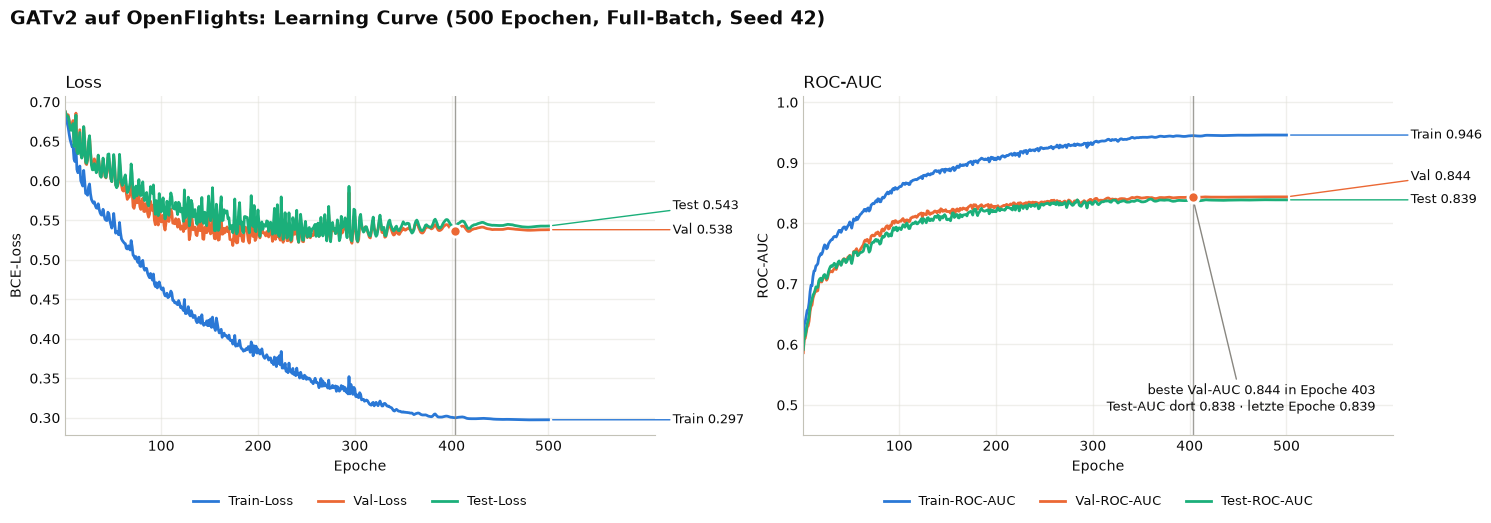

In [5]:
plot_learning_curves(history, title=f"{MODEL_NAME} auf OpenFlights: Learning Curve ({len(history['val_auc'])} Epochen, Full-Batch, Seed {SEED})")
plt.show()

## Mehr-Seed-Auswertung

Einzelne Läufe streuen (Initialisierung, Dropout). Für den Vergleich GINE ↔ GATv2 zählen Mittelwert ±
Standardabweichung über 5 Seeds, jeweils an der Epoche mit der besten Val-AUC. Neben der ROC-AUC wird die
Average Precision (AP) auf Test berichtet. Die Ergebnisse landen in `processed/seeds_<Modell>_OpenFlights.csv`
und werden in `Evaluation_OpenFlights.ipynb` zusammengeführt.

In [6]:
import os

SEEDS = [0, 1, 2, 3, 4]
SEED_CSV = f"processed/seeds_{MODEL_NAME}_OpenFlights.csv"
RUN_SEEDS = not os.path.exists(SEED_CSV)   # vorhandene Ergebnisse laden statt neu rechnen (~10-15 min auf CPU)

if RUN_SEEDS:
    seed_df, seed_histories = run_seeds(make_model, train_data, val_data, test_data, SEEDS, **TRAIN_KWARGS)
    seed_df.to_csv(SEED_CSV, index=False)
else:
    seed_df = pd.read_csv(SEED_CSV)
    print(f"Geladen: {SEED_CSV} (zum Neuberechnen Datei löschen)")
print(f"{len(seed_df)} Seeds: Val-AUC {seed_df['val_auc'].mean():.4f} ± {seed_df['val_auc'].std():.4f} | "
      f"Test-AUC {seed_df['test_auc'].mean():.4f} ± {seed_df['test_auc'].std():.4f} | Test-AP {seed_df['test_ap'].mean():.4f}")
seed_df

Seed 0: beste Val-AUC 0.8409 (Epoche 450), Test-AUC dort 0.8427
Seed 1: beste Val-AUC 0.8332 (Epoche 426), Test-AUC dort 0.8302
Seed 2: beste Val-AUC 0.8369 (Epoche 267), Test-AUC dort 0.8330
Seed 3: beste Val-AUC 0.8383 (Epoche 440), Test-AUC dort 0.8348
Seed 4: beste Val-AUC 0.8393 (Epoche 454), Test-AUC dort 0.8354

5 Seeds: Val-AUC 0.8378 ± 0.0029 | Test-AUC 0.8352 ± 0.0046
5 Seeds: Val-AUC 0.8378 ± 0.0029 | Test-AUC 0.8352 ± 0.0046 | Test-AP 0.8248


,seed,best_epoch,val_auc,test_auc,test_ap,test_loss
0,0,450,0.840932,0.842697,0.832045,0.547915
1,1,426,0.833222,0.830165,0.820331,0.551505
2,2,267,0.836934,0.833043,0.821713,0.551075
3,3,440,0.838341,0.834796,0.827265,0.548695
4,4,454,0.839332,0.835352,0.822667,0.553833


## Gegenprobe 1: Lernt das Modell aus dem Graphen oder nur aus den Knotenfeatures?

Gleiches Modell, gleiche Seeds, aber **ohne Message Passing**: Der Graph ist leer, jeder Knoten sieht nur seine
eigenen Features (Position, Höhe, Zeitzone, Region). Das Modell ist damit ein reines MLP auf den Knotenfeatures.
Liegt es deutlich unter dem GNN, stammt der Gewinn aus der Graphstruktur.

Standardmäßig aus (`RUN_CHECKS = False`), weil beide Gegenproben zusammen etwa 15–20 Minuten auf CPU brauchen.
Ergebnis aus dem Tuning-Lauf (GINE, ein Seed): ohne Graph Val-AUC 0.707 statt 0.823 mit Graph.

In [7]:
RUN_CHECKS = False   # True: beide Gegenproben rechnen (je Modell ~15-20 min auf CPU)

def without_graph(split):
    split = split.clone()
    split.edge_index = split.edge_index[:, :0]
    split.edge_attr = split.edge_attr[:0]
    return split

if RUN_CHECKS:
    no_graph_df, _ = run_seeds(make_model, *(without_graph(s) for s in (train_data, val_data, test_data)), SEEDS, **TRAIN_KWARGS)
    no_graph_df.to_csv(f"processed/seeds_{MODEL_NAME}_OpenFlights_ohne_graph.csv", index=False)
    display(pd.DataFrame({
        "mit Graph (GNN)": seed_df[["val_auc", "test_auc", "test_ap"]].agg(["mean", "std"]).stack(),
        "ohne Graph (nur Knotenfeatures)": no_graph_df[["val_auc", "test_auc", "test_ap"]].agg(["mean", "std"]).stack(),
    }).round(4))
else:
    print("Übersprungen (RUN_CHECKS = False).")

Übersprungen (RUN_CHECKS = False).


## Gegenprobe 2: Standardprotokoll mit zufälligen Negativen

In der Literatur werden Negative meist zufällig gezogen (z. B. PyG-Beispiel `link_pred.py`, GAE). Dort ist die
Aufgabe leichter, weil zufällige Flughafenpaare meist weit auseinander liegen (Luftlinie allein ≈ 0.94). Der Lauf
dient der Einordnung gegenüber solchen Zahlen; maßgeblich bleibt das faire Protokoll oben. Gleicher Seed für den
Split, also dieselben positiven Kanten und derselbe Message-Passing-Graph, nur andere Negative.

In [8]:
meta = bundle.meta
if RUN_CHECKS:
    uniform_splits = split_graph(
        data.cpu(), seed=meta["seed"], val_ratio=meta["val_ratio"], test_ratio=meta["test_ratio"],
        neg_sampling_ratio=meta["neg_sampling_ratio"], neg_strategy="uniform", supervision_ratio=meta["supervision_ratio"],
)
    uniform_splits = [s.to(device) for s in uniform_splits]
    uniform_df, _ = run_seeds(make_model, *uniform_splits, SEEDS[:3], **TRAIN_KWARGS)
    uniform_df.to_csv(f"processed/seeds_{MODEL_NAME}_OpenFlights_uniform.csv", index=False)
    display(uniform_df)
else:
    print("Übersprungen (RUN_CHECKS = False).")

Übersprungen (RUN_CHECKS = False).


## Visualisierung der Knoten-Embeddings

PCA der gelernten Embeddings (Modell der besten Val-Epoche aus dem ersten Lauf, auf dem Message-Passing-Graphen)
auf 2 Dimensionen. Links eingefärbt nach Weltregion (die drei größten Regionen, Rest grau), rechts nach Grad im
Message-Passing-Graphen. Bilden sich Regionen oder Hubs als Struktur ab, hat das Modell sie aus Features und
Graph gelernt.

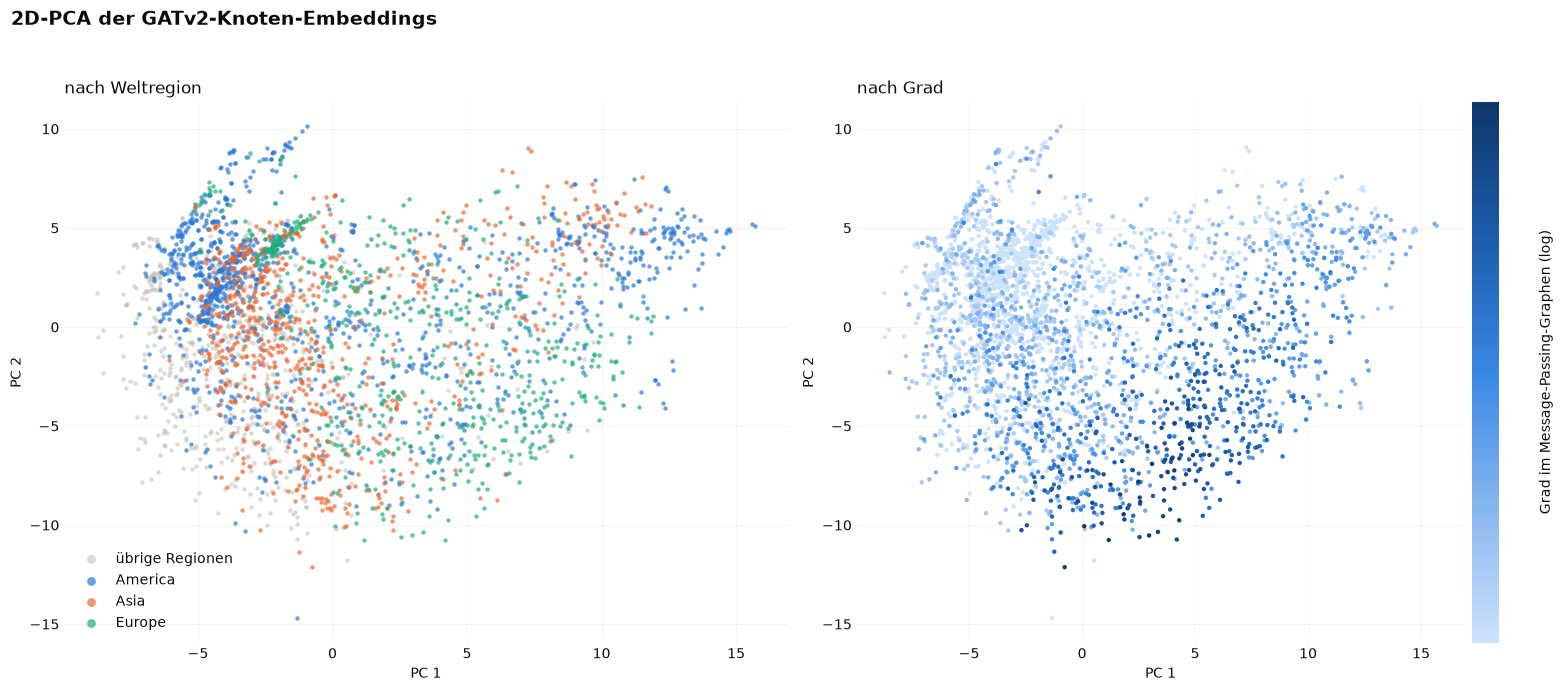

In [9]:
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from torch_geometric.utils import degree as pyg_degree

model.eval()
with torch.no_grad():
    emb = model(train_data.x, train_data.edge_index, train_data.edge_attr).cpu().numpy()
emb_2d = PCA(n_components=2).fit_transform(emb)
region = pd.Series(bundle.node_type)
deg_msg = pyg_degree(train_data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()

SURFACE, INK, MUTED, GRID = "#ffffff", "#0b0b0b", "#898781", "#e1e0d9"
top_regions = region.value_counts().index[:3]
colors = dict(zip(top_regions, ["#2a78d6", "#eb6834", "#1baf7a"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(SURFACE)
rest = ~region.isin(top_regions).values
ax1.scatter(emb_2d[rest, 0], emb_2d[rest, 1], s=10, color="#c3c2b7", alpha=0.6, label="übrige Regionen", linewidths=0)
for r in top_regions:
    m = (region == r).values
    ax1.scatter(emb_2d[m, 0], emb_2d[m, 1], s=10, color=colors[r], alpha=0.7, label=r, linewidths=0)
ax1.legend(frameon=False, labelcolor=INK, markerscale=2)
blues = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
order = np.argsort(deg_msg)
sc = ax2.scatter(emb_2d[order, 0], emb_2d[order, 1], c=np.maximum(deg_msg[order], 1), cmap=blues,
                 norm=LogNorm(1, max(deg_msg.max(), 2)), s=10, linewidths=0)
cbar = fig.colorbar(sc, ax=ax2, pad=0.01)
cbar.set_label("Grad im Message-Passing-Graphen (log)", color=INK); cbar.outline.set_visible(False)
for ax, title in [(ax1, "nach Weltregion"), (ax2, "nach Grad")]:
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=MUTED, labelcolor=INK, length=0)
    ax.set_xlabel("PC 1", color=INK); ax.set_ylabel("PC 2", color=INK)
    ax.set_title(title, loc="left", color=INK, fontsize=12)
fig.suptitle(f"2D-PCA der {MODEL_NAME}-Knoten-Embeddings", x=0.01, ha="left", color=INK, fontsize=14, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## Fehleranalyse: Wo liegt das Modell richtig, wo nicht?

ROC-AUC auf Test **innerhalb** von Gruppen, Positive werden also nur mit Negativen derselben Gruppe verglichen:

- **nach Entfernung:** Kurz- (< 1.000 km), Mittel- (1.000–3.000 km) und Langstrecke (> 3.000 km). Weil die
  Negativen entfernungsgleich gezogen sind, haben alle Gruppen Positive und Negative.
- **nach Hub-Größe:** Grad des größeren Endpunkts im Message-Passing-Graphen. Paare mit einem großen Hub sind
  schwer, weil ein Hub mit vielen, aber nicht allen Flughäfen verbunden ist.

Zum Vergleich steht daneben die AUC von Adamic-Adar in derselben Gruppe.

,positive Paare,negative Paare,ROC-AUC,mittlere Wahrscheinlichkeit (pos),mittlere Wahrscheinlichkeit (neg),ROC-AUC Adamic-Adar
Entfernung,,,,,,
< 1.000 km,1694,1338,0.784,0.674,0.343,0.663
1.000–3.000 km,1520,1704,0.862,0.792,0.325,0.805
> 3.000 km,558,730,0.905,0.837,0.257,0.887


,positive Paare,negative Paare,ROC-AUC,mittlere Wahrscheinlichkeit (pos),mittlere Wahrscheinlichkeit (neg),ROC-AUC Adamic-Adar
Grad des größeren Endpunkts,,,,,,
≤ 10,404,930,0.796,0.546,0.231,0.653
11–50,1580,1776,0.808,0.689,0.318,0.702
> 50,1788,1066,0.851,0.840,0.393,0.784


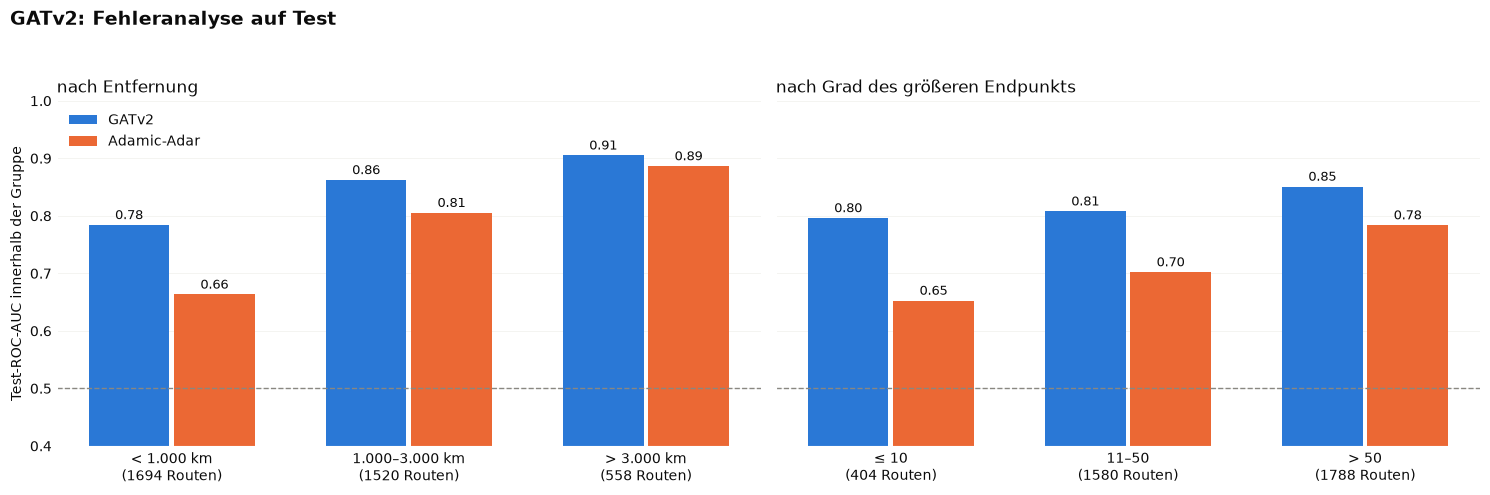

In [10]:
import scipy.sparse as sp
from sklearn.metrics import roc_auc_score

scores, labels = link_scores(model, test_data)
u, v = test_data.edge_label_index.cpu().numpy()
pos = test_data.pos.cpu().numpy()
chord = np.linalg.norm(pos[u] - pos[v], axis=1)
dist_km = 2 * 6371 * np.arcsin(np.clip(chord / (2 * 6371), 0, 1))
dist_bucket = pd.cut(dist_km, [0, 1000, 3000, 20000], labels=["< 1.000 km", "1.000–3.000 km", "> 3.000 km"]).astype(str)
hub_deg = np.maximum(deg_msg[u], deg_msg[v])
hub_bucket = pd.cut(hub_deg, [-1, 10, 50, 1000], labels=["≤ 10", "11–50", "> 50"]).astype(str)

ei = test_data.edge_index.cpu().numpy()
adj = sp.coo_matrix((np.ones(ei.shape[1]), (ei[0], ei[1])), shape=(data.num_nodes,) * 2).tocsr()
adj = ((adj + adj.T) > 0).astype(float)
inv_log = np.where(deg_msg > 1, 1 / np.log(np.maximum(deg_msg, 2)), 0)
adamic_adar = np.asarray(adj[u].multiply(adj[v] @ sp.diags(inv_log)).sum(axis=1)).ravel()

def with_baseline(buckets, name):
    df = auc_by_bucket(scores, labels, buckets, name)
    df["ROC-AUC Adamic-Adar"] = [roc_auc_score(labels[buckets == b], adamic_adar[buckets == b]) for b in df.index]
    return df

by_dist = with_baseline(dist_bucket, "Entfernung").loc[["< 1.000 km", "1.000–3.000 km", "> 3.000 km"]]
by_hub = with_baseline(hub_bucket, "Grad des größeren Endpunkts").loc[["≤ 10", "11–50", "> 50"]]
display(by_dist.round(3)); display(by_hub.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.patch.set_facecolor(SURFACE)
for ax, df, title in [(axes[0], by_dist, "nach Entfernung"), (axes[1], by_hub, "nach Grad des größeren Endpunkts")]:
    x = np.arange(len(df))
    ax.bar(x - 0.18, df["ROC-AUC"], width=0.34, color="#2a78d6", label=MODEL_NAME)
    ax.bar(x + 0.18, df["ROC-AUC Adamic-Adar"], width=0.34, color="#eb6834", label="Adamic-Adar")
    for xi, (a, b) in enumerate(zip(df["ROC-AUC"], df["ROC-AUC Adamic-Adar"])):
        ax.text(xi - 0.18, a + 0.01, f"{a:.2f}", ha="center", fontsize=9, color=INK)
        ax.text(xi + 0.18, b + 0.01, f"{b:.2f}", ha="center", fontsize=9, color=INK)
    ax.set_xticks(x, [f"{i}\n({p} Routen)" for i, p in zip(df.index, df["positive Paare"])])
    ax.axhline(0.5, color=MUTED, linewidth=1, linestyle="--")
    ax.set_ylim(0.4, 1.0)
    ax.set_facecolor(SURFACE); ax.grid(True, axis="y", color=GRID); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=MUTED, labelcolor=INK, length=0)
    ax.set_title(title, loc="left", color=INK, fontsize=12)
axes[0].set_ylabel("Test-ROC-AUC innerhalb der Gruppe", color=INK)
axes[0].legend(frameon=False, labelcolor=INK, loc="upper left")
fig.suptitle(f"{MODEL_NAME}: Fehleranalyse auf Test", x=0.01, ha="left", color=INK, fontsize=14, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()